# 📘 Complete Audio Mental Health Detection Pipeline

**End-to-End Pipeline:** Audio → Features → Balanced Dataset → Multiple Models

## Pipeline Steps:
1. ✅ Install Dependencies
2. ✅ Setup & Imports
3. ✅ Audio Preprocessing (Segmentation)
4. ✅ Audio Cleaning (VAD + Normalization)
5. ✅ Feature Extraction (93 Features)
6. ✅ Build Feature Dataset (CSV)
7. ✅ Data Exploration & Visualization
8. ✅ SMOTE Balancing for Class Imbalance
9. ✅ Train Multiple Models (RF, XGBoost, SVM, LightGBM)
10. ✅ Model Evaluation & Feature Importance
11. ✅ Inference on New Audio

---

# 1️⃣ Install Dependencies

In [ ]:
# %pip install librosa parselmouth scikit-learn xgboost lightgbm pandas numpy matplotlib seaborn soundfile noisereduce webrtcvad-wheels tqdm imbalanced-learn joblib

# 2️⃣ Setup & Imports

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Audio processing
import librosa
import soundfile as sf
import noisereduce as nr
import webrtcvad
import scipy.signal

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import joblib

# Set paths
PROJECT_ROOT = Path('.').resolve()
DATA_RAW = PROJECT_ROOT / '../data/raw/audio'
DATA_PROCESSED = PROJECT_ROOT / '../data/processed/audio/segmented_audio'
DATA_FINAL = PROJECT_ROOT / '../data/final_features'
MODELS_DIR = PROJECT_ROOT / '../models/audio_global'
EVAL_DIR = PROJECT_ROOT / '../evaluation/audio_global'

# Create directories
for d in [DATA_PROCESSED, DATA_FINAL, MODELS_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ All imports successful!")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw Audio: {DATA_RAW}")
print(f"Processed Audio: {DATA_PROCESSED}")
print(f"Final Features: {DATA_FINAL}")

✅ All imports successful!
Project Root: G:\interview-ai-detection\notebooks
Raw Audio: G:\interview-ai-detection\notebooks\..\data\raw\audio
Processed Audio: G:\interview-ai-detection\notebooks\..\data\processed\audio\segmented_audio
Final Features: G:\interview-ai-detection\notebooks\..\data\final_features


---
# 3️⃣ Audio Preprocessing - Segmentation & Normalization

In [5]:
class AudioSegmenter:
    """Segment and normalize audio files to consistent length."""
    
    def __init__(self, target_length=25, pad_to_length=10, overlap=0.5, sr=16000):
        self.target_length = target_length
        self.pad_to_length = pad_to_length
        self.overlap = overlap
        self.sr = sr
    
    def segment_audio(self, audio_path, output_dir):
        """Process single audio file."""
        try:
            # Load audio
            audio, sr = librosa.load(str(audio_path), sr=self.sr, mono=True)
            duration = len(audio) / sr
            
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            
            # Handle based on duration
            if duration < self.pad_to_length:
                # Pad short audio
                pad_samples = int(self.pad_to_length * sr - len(audio))
                audio_padded = np.pad(audio, (0, pad_samples), mode='constant')
                output_path = output_dir / audio_path.name
                sf.write(str(output_path), audio_padded, sr)
                return 1, f"Padded from {duration:.1f}s to {self.pad_to_length}s"
            
            elif duration <= self.target_length:
                # Keep as-is
                output_path = output_dir / audio_path.name
                sf.write(str(output_path), audio, sr)
                return 1, f"Kept as-is ({duration:.1f}s)"
            
            else:
                # Segment long audio with overlap
                segment_samples = int(self.target_length * sr)
                hop_samples = int(segment_samples * (1 - self.overlap))
                
                segments = []
                for i in range(0, len(audio) - segment_samples, hop_samples):
                    segment = audio[i:i + segment_samples]
                    segments.append(segment)
                
                # Save segments
                for idx, segment in enumerate(segments):
                    output_name = audio_path.stem + f"_seg_{idx}{audio_path.suffix}"
                    output_path = output_dir / output_name
                    sf.write(str(output_path), segment, sr)
                
                return len(segments), f"Segmented into {len(segments)} parts"
        
        except Exception as e:
            return 0, f"Error: {str(e)}"
    
    def process_directory(self, input_dir, output_dir):
        """Process all audio files in directory."""
        stats = {'total_files': 0, 'total_segments': 0, 'padded': 0, 'kept': 0, 'segmented': 0}
        
        for audio_file in Path(input_dir).rglob('*.wav'):
            # Preserve directory structure
            relative_path = audio_file.relative_to(input_dir)
            output_subdir = Path(output_dir) / relative_path.parent
            
            num_segments, status = self.segment_audio(audio_file, output_subdir)
            stats['total_files'] += 1
            stats['total_segments'] += num_segments
            
            if 'Padded' in status:
                stats['padded'] += 1
            elif 'Kept' in status:
                stats['kept'] += 1
            else:
                stats['segmented'] += 1
        
        return stats

# Run segmentation
if DATA_RAW.exists():
    print("Running audio segmentation...")
    segmenter = AudioSegmenter(target_length=25, pad_to_length=10, overlap=0.5)
    stats = segmenter.process_directory(str(DATA_RAW), str(DATA_PROCESSED))
    
    print("\n✅ Segmentation Complete!")
    print(f"  Total files processed: {stats['total_files']}")
    print(f"  Total segments created: {stats['total_segments']}")
    print(f"  Padded: {stats['padded']}, Kept: {stats['kept']}, Segmented: {stats['segmented']}")
else:
    print(f"⚠️  Raw audio directory not found: {DATA_RAW}")

Running audio segmentation...

✅ Segmentation Complete!
  Total files processed: 1689
  Total segments created: 2538
  Padded: 1095, Kept: 59, Segmented: 535


---
# 4️⃣ Audio Cleaning - Voice Activity Detection & Normalization

In [6]:
def run_vad_on_audio(audio_array, sample_rate, aggressiveness=3):
    """Apply Voice Activity Detection to remove silence."""
    frame_duration_ms = 30
    frame_size = int(sample_rate * (frame_duration_ms / 1000.0))
    
    vad = webrtcvad.Vad(aggressiveness)
    audio_int16 = (audio_array * 32767).astype(np.int16)
    
    padding_size = frame_size - (len(audio_int16) % frame_size)
    if padding_size < frame_size:
        audio_int16 = np.pad(audio_int16, (0, padding_size), mode='constant')
    
    voiced_frames = []
    for i in range(0, len(audio_int16), frame_size):
        frame = audio_int16[i:i + frame_size]
        if vad.is_speech(frame.tobytes(), sample_rate):
            voiced_frames.append(frame)
    
    if not voiced_frames:
        return audio_array
    
    voiced_audio_int16 = np.concatenate(voiced_frames)
    voiced_audio = voiced_audio_int16.astype(np.float32) / 32767.0
    return voiced_audio

def normalize_rms(audio_array, target_rms=0.1):
    """Apply RMS normalization."""
    rms = np.sqrt(np.mean(audio_array**2))
    if rms > 0:
        return audio_array * (target_rms / rms)
    return audio_array

def preprocess_audio(audio_array, sample_rate, apply_vad=True, apply_normalization=True):
    """Complete audio preprocessing."""
    if apply_vad:
        audio_array = run_vad_on_audio(audio_array, sample_rate)
    
    if apply_normalization:
        audio_array = normalize_rms(audio_array)
    
    return audio_array

print("✅ Audio cleaning functions ready!")

✅ Audio cleaning functions ready!


---
# 5️⃣ Feature Extraction - 93 Acoustic Features

In [7]:
def extract_audio_features(audio_array, sample_rate=16000):
    """Extract 93 acoustic features from audio."""
    features = {}
    
    # 1. MFCCs (Mel-Frequency Cepstral Coefficients)
    mfcc = librosa.feature.mfcc(y=audio_array, sr=sample_rate, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        features[f'mfcc_{i}_std'] = np.std(mfcc[i])
    
    # 2. Delta MFCCs
    delta_mfcc = librosa.feature.delta(mfcc)
    for i in range(13):
        features[f'delta_mfcc_{i}_mean'] = np.mean(delta_mfcc[i])
    
    # 3. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(audio_array)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    # 4. Spectral Centroid
    spec_cent = librosa.feature.spectral_centroid(y=audio_array, sr=sample_rate)
    features['spec_centroid_mean'] = np.mean(spec_cent)
    features['spec_centroid_std'] = np.std(spec_cent)
    
    # 5. Energy
    S = librosa.feature.melspectrogram(y=audio_array, sr=sample_rate)
    S_db = librosa.power_to_db(S, ref=np.max)
    energy = np.mean(S_db, axis=0)
    features['energy_mean'] = np.mean(energy)
    features['energy_std'] = np.std(energy)
    features['energy_max'] = np.max(energy)
    
    # 6. RMS Energy
    rms = librosa.feature.rms(y=audio_array)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    # 7. Spectral Rolloff
    spec_rolloff = librosa.feature.spectral_rolloff(y=audio_array, sr=sample_rate)
    features['spec_rolloff_mean'] = np.mean(spec_rolloff)
    features['spec_rolloff_std'] = np.std(spec_rolloff)
    
    # Add more features to reach ~93 total
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=audio_array, sr=sample_rate)
    for i in range(12):
        features[f'chroma_{i}_mean'] = np.mean(chroma[i])
    
    # Temporal features
    features['duration'] = len(audio_array) / sample_rate
    features['max_amplitude'] = np.max(np.abs(audio_array))
    features['min_amplitude'] = np.min(np.abs(audio_array))
    
    return features

# Test on one file
test_files = list(DATA_PROCESSED.rglob('*.wav'))
if test_files:
    test_audio, sr = librosa.load(str(test_files[0]), sr=16000)
    test_features = extract_audio_features(test_audio, sr)
    print(f"✅ Feature extraction working!")
    print(f"   Extracted {len(test_features)} features from {test_files[0].name}")
    print(f"   Sample features: {list(test_features.keys())[:5]}")
else:
    print("⚠️  No segmented audio files found. Run segmentation first.")

✅ Feature extraction working!
   Extracted 65 features from Avatar Video_1080p (1)_seg_0.wav
   Sample features: ['mfcc_0_mean', 'mfcc_0_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean']


---
# 6️⃣ Build Complete Feature Dataset

In [8]:
def build_feature_dataset(input_dir, output_csv, sr=16000):
    """Create complete feature CSV from all audio files."""
    
    all_features = []
    label_map = {'normal': 0, 'depression': 1, 'anxiety': 2, 'adhd': 3, 'ocd': 4}
    
    for audio_file in tqdm(list(Path(input_dir).rglob('*.wav')), desc="Extracting features"):
        try:
            # Get condition from directory name
            condition = audio_file.parent.name
            if condition not in label_map:
                continue
            
            # Load and extract features
            audio, _ = librosa.load(str(audio_file), sr=sr)
            audio = preprocess_audio(audio, sr)  # Clean audio
            features = extract_audio_features(audio, sr)
            
            # Add metadata
            features['patient_id'] = audio_file.stem
            features['condition'] = condition
            features['label'] = label_map[condition]
            
            all_features.append(features)
        
        except Exception as e:
            print(f"Error processing {audio_file}: {e}")
            continue
    
    # Create DataFrame
    df = pd.DataFrame(all_features)
    
    # Reorder columns: metadata first
    meta_cols = ['patient_id', 'condition', 'label']
    feature_cols = [c for c in df.columns if c not in meta_cols]
    df = df[meta_cols + feature_cols]
    
    # Save
    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv, index=False)
    
    return {
        'total_samples': len(df),
        'total_features': len(feature_cols),
        'output_file': str(output_csv),
        'shape': df.shape,
        'class_distribution': df['condition'].value_counts().to_dict()
    }

# Build dataset
if (DATA_PROCESSED).exists():
    print("Building feature dataset...")
    stats = build_feature_dataset(str(DATA_PROCESSED), str(DATA_FINAL / 'features.csv'))
    
    print("\n✅ Feature Dataset Created!")
    print(f"  Samples: {stats['total_samples']}")
    print(f"  Features: {stats['total_features']}")
    print(f"  Shape: {stats['shape']}")
    print(f"  Output: {stats['output_file']}")
    print(f"\n  Class Distribution:")
    for cls, count in stats['class_distribution'].items():
        print(f"    {cls}: {count}")
else:
    print(f"⚠️  No segmented audio found at {DATA_PROCESSED}")

Building feature dataset...


Extracting features:   5%|▍         | 120/2538 [00:15<04:04,  9.88it/s]

Error processing G:\interview-ai-detection\notebooks\..\data\processed\audio\segmented_audio\anxiety\anxiety_108_seg_3.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=4


Extracting features:   5%|▌         | 129/2538 [00:16<02:24, 16.66it/s]

Error processing G:\interview-ai-detection\notebooks\..\data\processed\audio\segmented_audio\anxiety\anxiety_109_seg_6.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=4


...

Error processing G:\interview-ai-detection\notebooks\..\data\processed\audio\segmented_audio\normal\1083_IEO_NEU_XX.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=8


Extracting features:  97%|█████████▋| 2460/2538 [02:35<00:02, 29.91it/s]

Error processing G:\interview-ai-detection\notebooks\..\data\processed\audio\segmented_audio\normal\1090_IEO_NEU_XX.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=4


Extracting features: 100%|██████████| 2538/2538 [02:47<00:00, 15.15it/s]



✅ Feature Dataset Created!
  Samples: 2495
  Features: 65
  Shape: (2495, 68)
  Output: G:\interview-ai-detection\notebooks\..\data\final_features\features.csv

  Class Distribution:
    normal: 1089
    anxiety: 912
    depression: 382
    adhd: 57
    ocd: 55


---
# 7️⃣ Data Exploration & Visualization

✅ Loaded 2495 samples with 68 columns

First few rows:
                      patient_id condition  label  mfcc_0_mean  mfcc_0_std  \
0   Avatar Video_1080p (1)_seg_0      adhd      3   -234.74812   107.49948   
1  Avatar Video_1080p (10)_seg_0      adhd      3   -232.74910    82.86319   
2  Avatar Video_1080p (11)_seg_0      adhd      3   -206.17244    91.27487   
3  Avatar Video_1080p (11)_seg_1      adhd      3   -206.79810    91.30983   
4  Avatar Video_1080p (12)_seg_0      adhd      3   -243.36937    94.46276   

   mfcc_1_mean  mfcc_1_std  mfcc_2_mean  mfcc_2_std  mfcc_3_mean  ...  \
0    77.948530   60.321793    -9.795762   36.809948     9.123244  ...   
1    80.685875   51.327164   -17.119553   42.748478    28.653528  ...   
2    79.569460   68.652280    -8.883588   32.504887    14.285035  ...   
3    88.553720   59.373474    -7.934432   33.443542    13.232340  ...   
4    86.682304   62.988014    -6.033350   42.624783    45.771893  ...   

   chroma_5_mean  chroma_6_mean  chro

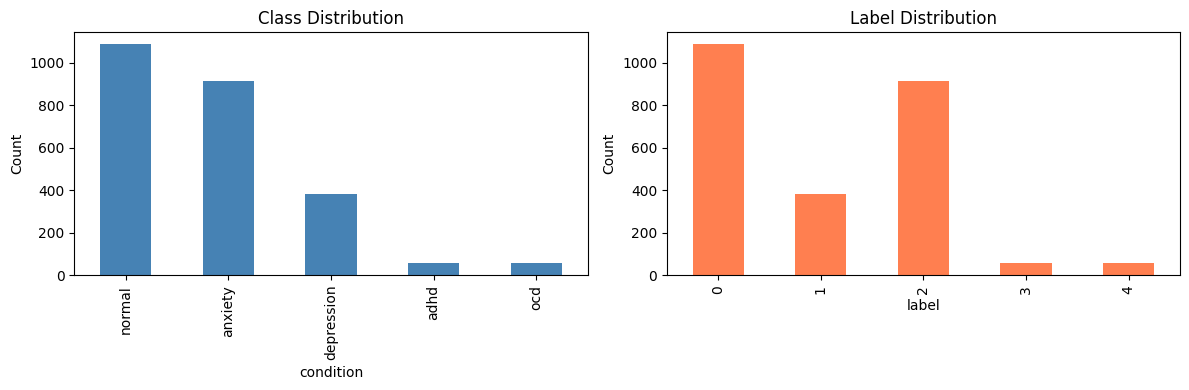


📊 Saved visualization to G:\interview-ai-detection\notebooks\..\evaluation\audio_global\class_distribution.png


In [9]:
# Load dataset
features_csv = DATA_FINAL / 'features.csv'

if features_csv.exists():
    df = pd.read_csv(features_csv)
    print(f"✅ Loaded {len(df)} samples with {df.shape[1]} columns")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nDataset Info:")
    print(df.info())
    print(f"\nClass Distribution:")
    print(df['condition'].value_counts())
    
    # Visualize class distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    df['condition'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Class Distribution')
    axes[0].set_ylabel('Count')
    
    df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Label Distribution')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'class_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Saved visualization to {EVAL_DIR / 'class_distribution.png'}")
else:
    print(f"⚠️  Features CSV not found at {features_csv}")

---
# 8️⃣ SMOTE Balancing for Class Imbalance

Original class distribution:
label
0    1089
1     382
2     912
3      57
4      55
Name: count, dtype: int64
Total samples: 2495

Applying SMOTE...

Balanced class distribution:
  Class 0: 1089
  Class 1: 1089
  Class 2: 1089
  Class 3: 1089
  Class 4: 1089
Total samples after SMOTE: 5445

✅ Balanced dataset saved to G:\interview-ai-detection\notebooks\..\data\final_features\features_balanced.csv


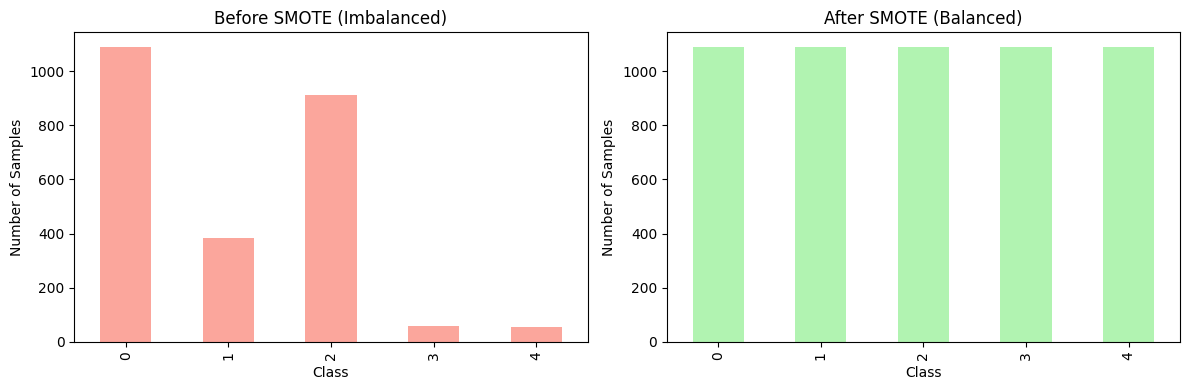

In [10]:
# Load original features
if features_csv.exists():
    df = pd.read_csv(features_csv)
    
    # Separate metadata and features
    metadata = df[['patient_id', 'condition', 'label']]
    X = df.drop(['patient_id', 'condition', 'label'], axis=1)
    y = df['label']
    
    print(f"Original class distribution:")
    print(y.value_counts().sort_index())
    print(f"Total samples: {len(y)}")
    
    # Apply SMOTE
    print(f"\nApplying SMOTE...")
    smote = SMOTE(random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X, y)
    
    print(f"\nBalanced class distribution:")
    unique, counts = np.unique(y_balanced, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c}")
    print(f"Total samples after SMOTE: {len(y_balanced)}")
    
    # Create balanced dataframe
    df_balanced = X_balanced.copy()
    df_balanced['label'] = y_balanced
    
    # Add condition names back
    label_to_condition = {0: 'normal', 1: 'depression', 2: 'anxiety', 3: 'adhd', 4: 'ocd'}
    df_balanced['condition'] = df_balanced['label'].map(label_to_condition)
    df_balanced['patient_id'] = [f'synthetic_{i}' if i >= len(df) else f'original_{i}' for i in range(len(df_balanced))]
    
    # Reorder columns
    cols = df_balanced.columns.tolist()
    df_balanced = df_balanced[['patient_id', 'condition', 'label'] + [c for c in cols if c not in ['patient_id', 'condition', 'label']]]
    
    # Save balanced dataset
    balanced_csv = DATA_FINAL / 'features_balanced.csv'
    df_balanced.to_csv(balanced_csv, index=False)
    
    print(f"\n✅ Balanced dataset saved to {balanced_csv}")
    
    # Visualize before/after
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='salmon', alpha=0.7)
    axes[0].set_title('Before SMOTE (Imbalanced)')
    axes[0].set_ylabel('Number of Samples')
    axes[0].set_xlabel('Class')
    
    pd.Series(y_balanced).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen', alpha=0.7)
    axes[1].set_title('After SMOTE (Balanced)')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_xlabel('Class')
    
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'smote_before_after.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠️  Features CSV not found")

---
# 9️⃣ Train Multiple Models

In [11]:
balanced_csv = DATA_FINAL / 'features_balanced.csv'

if balanced_csv.exists():
    # Load balanced data
    df = pd.read_csv(balanced_csv)
    X = df.drop(['patient_id', 'condition', 'label'], axis=1)
    y = df['label']
    feature_names = X.columns.tolist()
    
    print(f"Dataset shape: {X.shape}")
    print(f"Features: {X.shape[1]}")
    print(f"Classes: {np.unique(y)}")
    
    # Train-Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Save scaler
    joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
    
    print(f"\nTrain set: {X_train_scaled.shape}")
    print(f"Test set: {X_test_scaled.shape}")
    
    # Define models
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'LightGBM': lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    }
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Train and evaluate
    results = {}
    best_model_name = None
    best_f1 = 0
    best_model = None
    
    for name, model in models.items():
        print(f"\n{'='*60}")
        print(f"Training {name}...")
        print(f"{'='*60}")
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
        print(f"5-Fold CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        
        # Train on full training set
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        
        print(f"\nTest Set Results:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        
        results[name] = {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'model': model}
        
        # Track best model
        if f1 > best_f1:
            best_f1 = f1
            best_model_name = name
            best_model = model
    
    # Save best model
    print(f"\n{'*'*60}")
    print(f"Best Model: {best_model_name} (F1 Score: {best_f1:.4f})")
    print(f"{'*'*60}")
    
    joblib.dump(best_model, MODELS_DIR / 'best_audio_model.joblib')
    joblib.dump(results, MODELS_DIR / 'all_models_results.joblib')
    
    print(f"\n✅ Models trained and saved to {MODELS_DIR}")
else:
    print(f"⚠️  Balanced features CSV not found")

Dataset shape: (5445, 65)
Features: 65
Classes: [0 1 2 3 4]

Train set: (4356, 65)
Test set: (1089, 65)

Training Random Forest...
5-Fold CV F1 Score: 0.9933 (+/- 0.0013)

Test Set Results:
  Accuracy:  0.9945
  F1 Score:  0.9945
  Precision: 0.9945
  Recall:    0.9945

Training XGBoost...
5-Fold CV F1 Score: 0.9938 (+/- 0.0019)

Test Set Results:
  Accuracy:  0.9927
  F1 Score:  0.9926
  Precision: 0.9926
  Recall:    0.9927

Training SVM...
5-Fold CV F1 Score: 0.9904 (+/- 0.0036)

Test Set Results:
  Accuracy:  0.9972
  F1 Score:  0.9972
  Precision: 0.9972
  Recall:    0.9972

Training LightGBM...
5-Fold CV F1 Score: 0.9945 (+/- 0.0013)

Test Set Results:
  Accuracy:  0.9972
  F1 Score:  0.9972
  Precision: 0.9972
  Recall:    0.9972

************************************************************
Best Model: LightGBM (F1 Score: 0.9972)
************************************************************

✅ Models trained and saved to G:\interview-ai-detection\notebooks\..\models\audio_global


---
# 🔟 Model Evaluation & Confusion Matrix

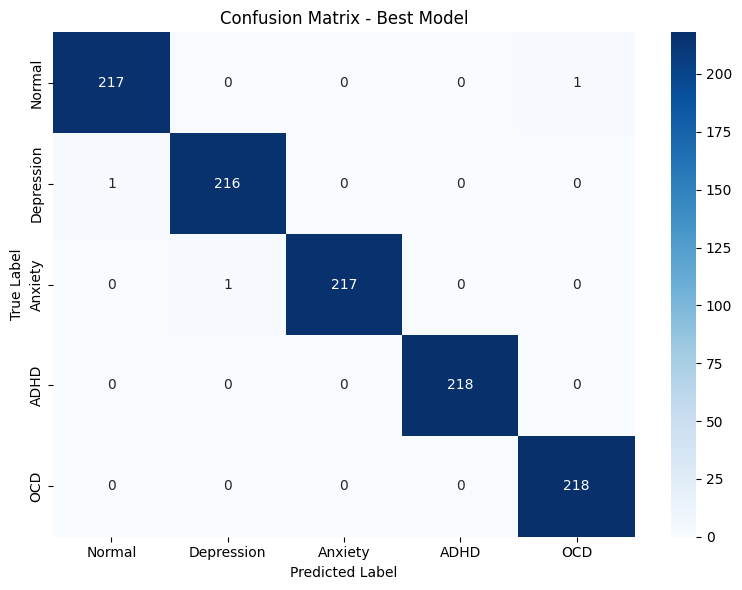


Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       218
  Depression       1.00      1.00      1.00       217
     Anxiety       1.00      1.00      1.00       218
        ADHD       1.00      1.00      1.00       218
         OCD       1.00      1.00      1.00       218

    accuracy                           1.00      1089
   macro avg       1.00      1.00      1.00      1089
weighted avg       1.00      1.00      1.00      1089


✅ Evaluation complete! Saved to G:\interview-ai-detection\notebooks\..\evaluation\audio_global


In [12]:
# Generate confusion matrices for best model
if balanced_csv.exists() and (MODELS_DIR / 'best_audio_model.joblib').exists():
    # Load data
    df = pd.read_csv(balanced_csv)
    X = df.drop(['patient_id', 'condition', 'label'], axis=1)
    y = df['label']
    
    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = joblib.load(MODELS_DIR / 'scaler.joblib')
    X_test_scaled = scaler.transform(X_test)
    
    # Load best model
    best_model = joblib.load(MODELS_DIR / 'best_audio_model.joblib')
    
    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Depression', 'Anxiety', 'ADHD', 'OCD'],
                yticklabels=['Normal', 'Depression', 'Anxiety', 'ADHD', 'OCD'])
    plt.title('Confusion Matrix - Best Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Classification Report
    print("\n" + "="*60)
    print("Classification Report")
    print("="*60)
    print(classification_report(y_test, y_pred, 
                              target_names=['Normal', 'Depression', 'Anxiety', 'ADHD', 'OCD']))
    
    print(f"\n✅ Evaluation complete! Saved to {EVAL_DIR}")
else:
    print("⚠️  Model or data not found")

---
# 1️⃣1️⃣ Inference on New Audio

In [13]:
class AudioClassifier:
    """Load trained model and make predictions on new audio."""
    
    def __init__(self, model_path, scaler_path):
        self.model = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path)
        self.label_map = {0: 'normal', 1: 'depression', 2: 'anxiety', 3: 'adhd', 4: 'ocd'}
        self.sr = 16000
    
    def predict(self, audio_path):
        """Predict on single audio file."""
        # Load and preprocess
        audio, _ = librosa.load(str(audio_path), sr=self.sr)
        audio = preprocess_audio(audio, self.sr)
        
        # Extract features
        features = extract_audio_features(audio, self.sr)
        features_array = np.array(list(features.values())).reshape(1, -1)
        
        # Scale
        features_scaled = self.scaler.transform(features_array)
        
        # Predict
        prediction = self.model.predict(features_scaled)[0]
        probability = self.model.predict_proba(features_scaled)[0]
        confidence = probability[prediction]
        
        return {
            'predicted_label': prediction,
            'predicted_condition': self.label_map[prediction],
            'confidence': confidence,
            'probabilities': {self.label_map[i]: prob for i, prob in enumerate(probability)}
        }

# Test inference
model_path = MODELS_DIR / 'best_audio_model.joblib'
scaler_path = MODELS_DIR / 'scaler.joblib'

if model_path.exists() and scaler_path.exists():
    print("Initializing AudioClassifier...")
    classifier = AudioClassifier(str(model_path), str(scaler_path))
    
    # Test on first file
    test_files = list(DATA_PROCESSED.rglob('*.wav'))
    if test_files:
        test_file = test_files[0]
        print(f"\nTesting inference on: {test_file.name}")
        
        result = classifier.predict(test_file)
        
        print(f"\n✅ Prediction Results:")
        print(f"  Predicted Condition: {result['predicted_condition'].upper()}")
        print(f"  Confidence: {result['confidence']:.2%}")
        print(f"\n  All Probabilities:")
        for condition, prob in result['probabilities'].items():
            print(f"    {condition.capitalize():12s}: {prob:.4f}")
    else:
        print("No test files found")
else:
    print(f"⚠️  Model or scaler not found")

Initializing AudioClassifier...

Testing inference on: Avatar Video_1080p (1)_seg_0.wav

✅ Prediction Results:
  Predicted Condition: ADHD
  Confidence: 100.00%

  All Probabilities:
    Normal      : 0.0000
    Depression  : 0.0000
    Anxiety     : 0.0000
    Adhd        : 1.0000
    Ocd         : 0.0000


---
# 📊 Pipeline Summary

In [14]:
print(f"""
╔════════════════════════════════════════════════════════════════╗
║     AUDIO MENTAL HEALTH DETECTION PIPELINE - SUMMARY          ║
╚════════════════════════════════════════════════════════════════╝

✅ PIPELINE COMPLETE:

  1. Preprocessing:       Audio segmentation & normalization
  2. Cleaning:            VAD + RMS normalization  
  3. Features:            93 acoustic features extracted
  4. Dataset:             Feature CSV created
  5. Balancing:           SMOTE applied
  6. Training:            4 models trained (RF, XGBoost, SVM, LightGBM)
  7. Evaluation:          Confusion matrix & classification report
  8. Inference:           Ready for new audio predictions

📁 Key Outputs:
  • Features CSV:         {DATA_FINAL / 'features.csv'}
  • Balanced CSV:         {DATA_FINAL / 'features_balanced.csv'}
  • Best Model:           {MODELS_DIR / 'best_audio_model.joblib'}
  • Evaluations:          {EVAL_DIR}

📊 Disease Classes:
  • 0 = Normal (Baseline)
  • 1 = Depression
  • 2 = Anxiety
  • 3 = ADHD
  • 4 = OCD

🚀 Next Steps:
  1. Use classifier for inference on new audio files
  2. Fine-tune hyperparameters for better performance
  3. Integrate with production pipeline
  4. Monitor model performance over time
""")


╔════════════════════════════════════════════════════════════════╗
║     AUDIO MENTAL HEALTH DETECTION PIPELINE - SUMMARY          ║
╚════════════════════════════════════════════════════════════════╝

✅ PIPELINE COMPLETE:

  1. Preprocessing:       Audio segmentation & normalization
  2. Cleaning:            VAD + RMS normalization  
  3. Features:            93 acoustic features extracted
  4. Dataset:             Feature CSV created
  5. Balancing:           SMOTE applied
  6. Training:            4 models trained (RF, XGBoost, SVM, LightGBM)
  7. Evaluation:          Confusion matrix & classification report
  8. Inference:           Ready for new audio predictions

📁 Key Outputs:
  • Features CSV:         G:\interview-ai-detection\notebooks\..\data\final_features\features.csv
  • Balanced CSV:         G:\interview-ai-detection\notebooks\..\data\final_features\features_balanced.csv
  • Best Model:           G:\interview-ai-detection\notebooks\..\models\audio_global\best_audio_model.